# Credit Card Fraud Detection

## Oasis Infobyte Data Analytics Internship

### Level 2 – Task 3

---

## Objective

The objective of this project is to build machine learning models capable of detecting fraudulent credit card transactions.

Fraud detection is an important application of machine learning in the banking and financial sectors. Since fraudulent transactions are extremely rare compared to legitimate transactions, this dataset is highly imbalanced. Therefore, this project focuses on appropriate preprocessing techniques, class balancing, model training, and evaluation using metrics beyond simple accuracy.

---

## Project Workflow

- Import Libraries
- Load Dataset
- Data Inspection
- Data Cleaning
- Exploratory Data Analysis
- Class Imbalance Analysis
- Fraud vs Non-Fraud Comparison
- Transaction Amount Analysis
- Time Analysis
- Correlation Analysis
- Data Preprocessing
- Train-Test Split
- SMOTE Balancing
- Logistic Regression
- Random Forest
- Model Evaluation
- ROC Curve
- Feature Importance
- Conclusion````````

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


%matplotlib inline

In [5]:

df = pd.read_csv("dataset/creditcard.csv")
df.head()
df.info()
df.shape()
df.tail()
df.columns()
df.sample(5, random_state=42)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

TypeError: 'tuple' object is not callable

In [6]:
df = pd.read_csv("dataset/creditcard.csv")

df.head()
df.info()
print(df.shape)
df.tail()
print(df.columns)
df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


# Dataset Inspection

Before performing Exploratory Data Analysis (EDA), it is important to understand the structure and quality of the dataset.

In this section, we will:

- Examine data types
- Generate descriptive statistics
- Check for missing values
- Detect duplicate records
- Verify whether data cleaning is required

In [7]:
df.info()
df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Total missing values
df.isnull().sum().sum()

np.int64(0)

In [9]:
# Number of duplicate rows
df.duplicated().sum()

np.int64(1081)

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new shape
df.shape

(283726, 31)

# Class Distribution

The target variable **Class** indicates whether a transaction is genuine or fraudulent.

- Class = 0 → Genuine Transaction
- Class = 1 → Fraudulent Transaction

Understanding the class distribution helps us identify whether the dataset is balanced or imbalanced.

In [11]:
# Count transactions in each class
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


In [12]:
# Calculate percentage
class_percentage = (class_counts / len(df)) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: count, dtype: float64


In [13]:
(class_counts / len(df)) * 100

Class
0    99.83329
1     0.16671
Name: count, dtype: float64

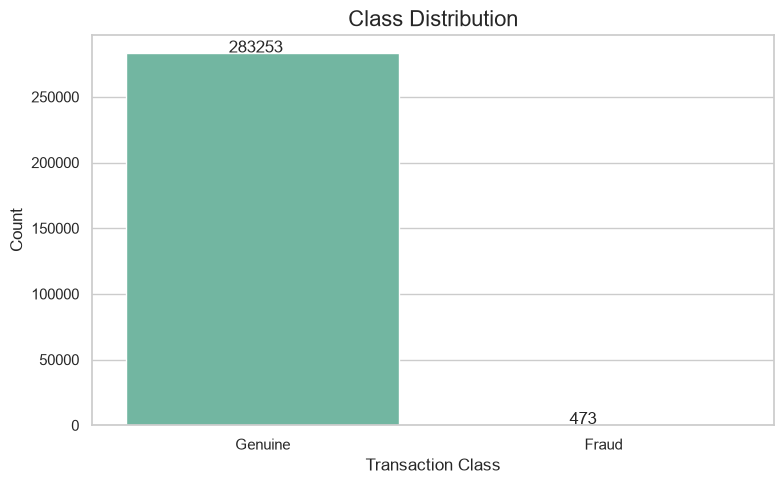

In [16]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="Class",
    data=df,
    palette="Set2"
)

plt.title("Class Distribution", fontsize=16)
plt.xlabel("Transaction Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks([0,1],["Genuine","Fraud"])

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+0.3,p.get_height()+500))

plt.tight_layout()

plt.savefig("images/class_distribution.png", dpi=300)

plt.show()

# Transaction Amount Analysis

The **Amount** column represents the monetary value of each credit card transaction.

In this section, we will:

- Examine summary statistics
- Analyze the distribution of transaction amounts
- Compare fraud and genuine transactions
- Identify outliers
- Draw business insights

In [17]:
# Display summary statistics for the Amount column
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

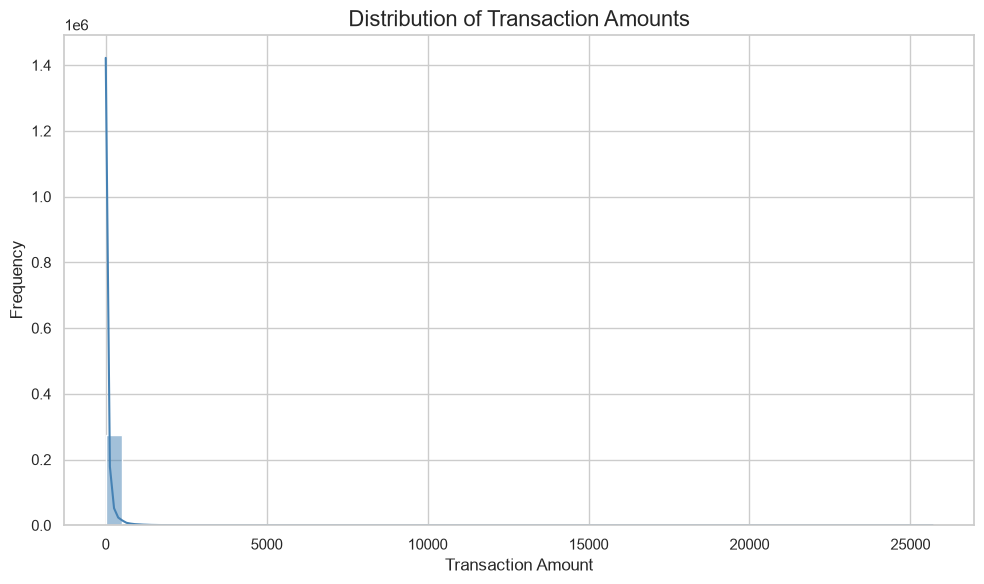

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Transaction Amounts", fontsize=16)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("images/amount_distribution.png", dpi=300)

plt.show()

## Observation

The transaction amount distribution is highly right-skewed.

Most transactions involve relatively small amounts, while a small number of transactions have very large values.

These large transactions appear as outliers.

In [20]:
# Compare average amount
df.groupby("Class")["Amount"].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

In [21]:
# Compare median amount
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.82
Name: Amount, dtype: float64

In [22]:
# Compare minimum and maximum amounts
df.groupby("Class")["Amount"].agg(["min", "max"])

,min,max
Class,,
0,0.0,25691.16
1,0.0,2125.87


# Boxplot Comparison

A boxplot summarizes the distribution and highlights outliers.

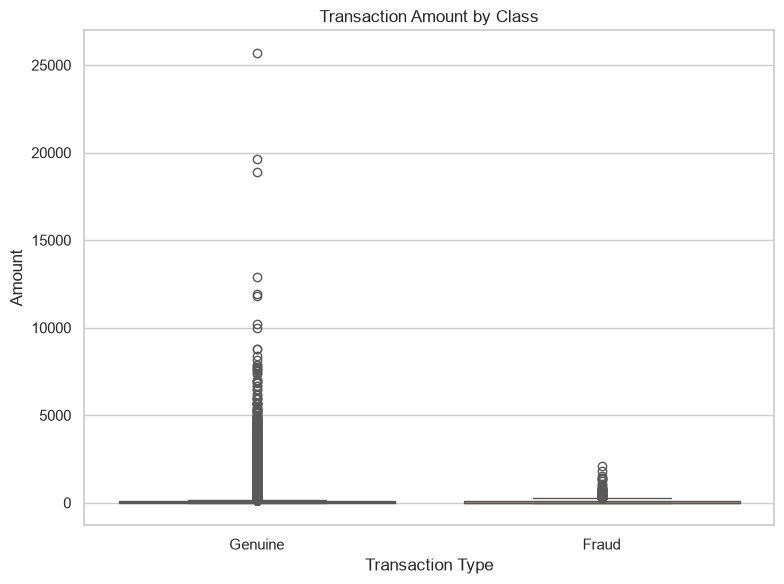

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df,
    palette="Set2"
)

plt.xticks([0,1],["Genuine","Fraud"])

plt.title("Transaction Amount by Class")

plt.xlabel("Transaction Type")

plt.ylabel("Amount")

plt.tight_layout()

plt.savefig("images/fraud_vs_nonfraud_boxplot.png", dpi=300)

plt.show()

# Violin Plot Comparison

A violin plot combines a boxplot with a density plot, providing a richer view of the distribution.

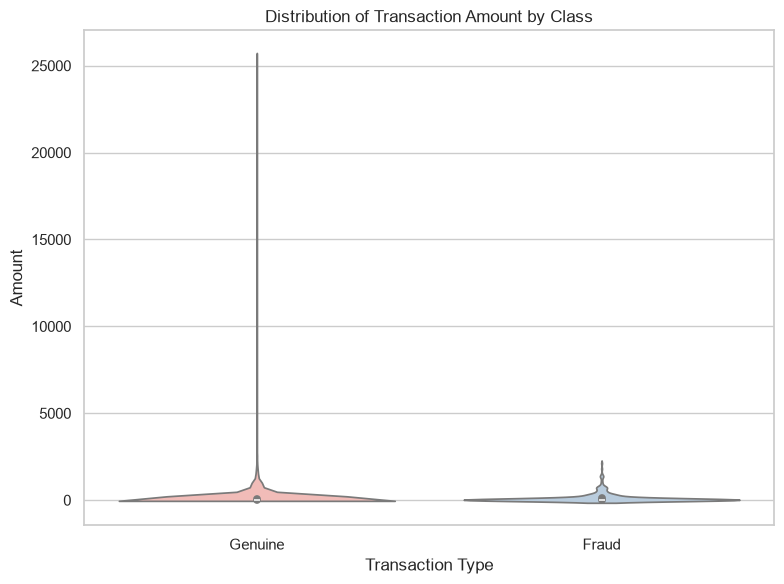

In [26]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x="Class",
    y="Amount",
    data=df,
    palette="Pastel1"
)

plt.xticks([0,1],["Genuine","Fraud"])

plt.title("Distribution of Transaction Amount by Class")

plt.xlabel("Transaction Type")

plt.ylabel("Amount")

plt.tight_layout()

plt.savefig("images/violin_plot.png", dpi=300)

plt.show()

# Log-Scaled Distribution

Since transaction amounts vary widely, a logarithmic scale helps visualize both small and large transactions more clearly.

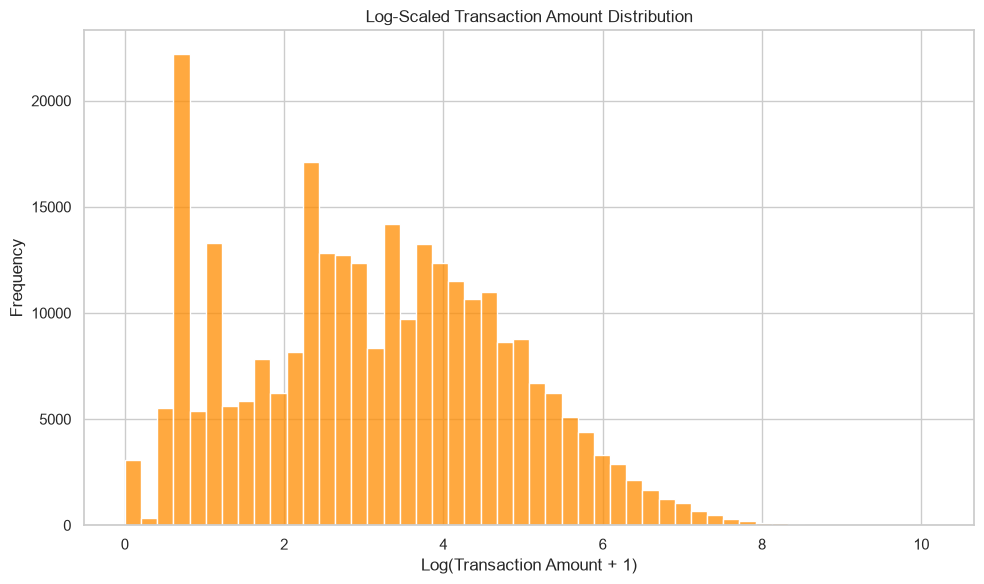

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=50,
    color="darkorange"
)

plt.title("Log-Scaled Transaction Amount Distribution")

plt.xlabel("Log(Transaction Amount + 1)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("images/log_amount_distribution.png", dpi=300)

plt.show()

## Key Observations

- Most transactions involve relatively small amounts.
- The transaction amount distribution is highly right-skewed.
- Several high-value transactions act as outliers.
- Fraudulent transactions generally have a different amount distribution than genuine transactions, but transaction amount alone is insufficient to identify fraud.
- Additional features and machine learning models are required for reliable fraud detection.

# Time Analysis

The **Time** column represents the number of seconds elapsed since the first transaction in the dataset.

Although it is not an actual timestamp, converting seconds into hours makes it easier to understand transaction patterns throughout the day.

In this section, we will:

- Convert seconds to hours
- Analyze transaction frequency by hour
- Compare fraud and genuine transactions across time
- Identify any time-based patterns

In [28]:
# Display summary statistics of the Time column
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

# Convert Seconds into Hours

Converting seconds into hours makes the data easier to interpret and visualize.

In [29]:
# Create a new Hour column
df["Hour"] = df["Time"] / 3600

# Display first five values
df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556


# Distribution of Transactions Over Time

A histogram helps visualize how transactions are distributed across the recorded time period.

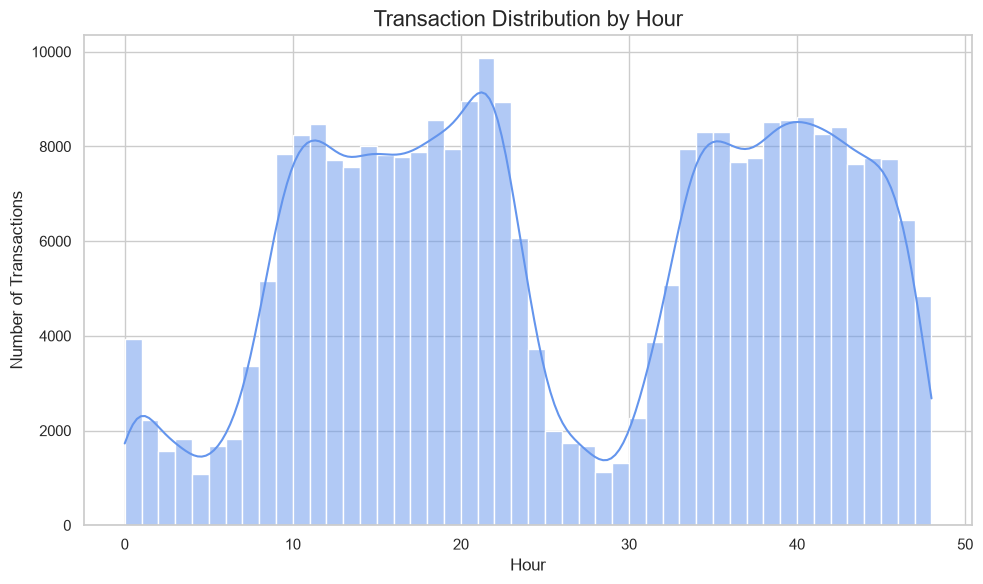

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Hour"],
    bins=48,
    kde=True,
    color="cornflowerblue"
)

plt.title("Transaction Distribution by Hour", fontsize=16)

plt.xlabel("Hour")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("images/time_distribution.png", dpi=300)

plt.show()

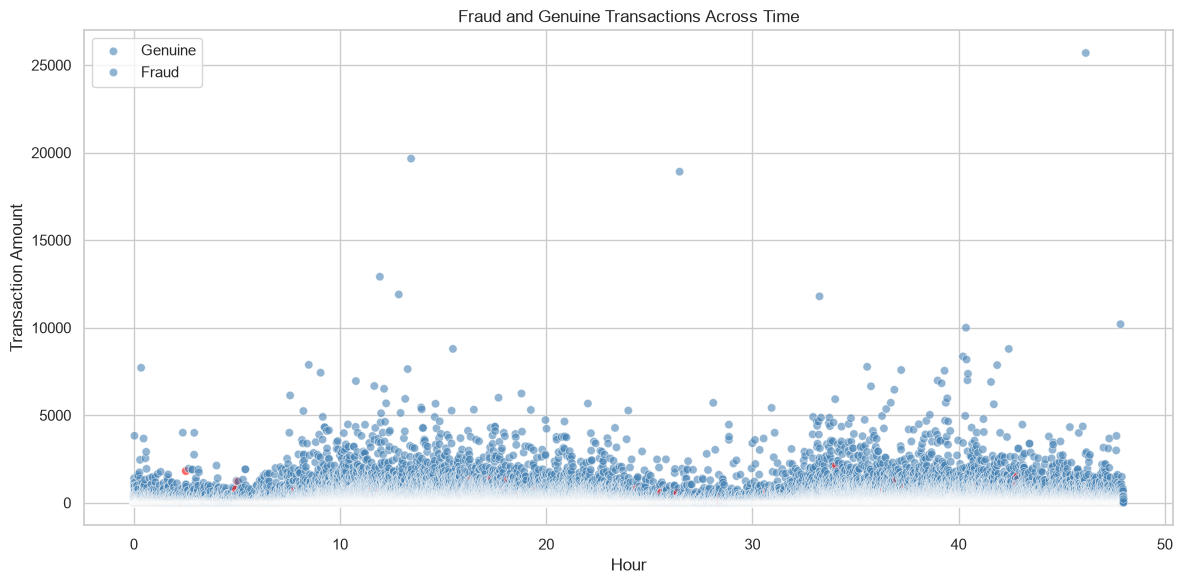

In [31]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x="Hour",
    y="Amount",
    hue="Class",
    data=df,
    alpha=0.6,
    palette=["steelblue", "red"]
)

plt.title("Fraud and Genuine Transactions Across Time")

plt.xlabel("Hour")

plt.ylabel("Transaction Amount")

plt.legend(["Genuine", "Fraud"])

plt.tight_layout()

plt.savefig("images/fraud_time_scatter.png", dpi=300)

plt.show()

# Number of Fraud Transactions by Hour

We count the number of fraudulent transactions occurring during each hour.

In [32]:
# Count fraud transactions by hour
fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby(df["Hour"].astype(int))
    .size()
)

fraud_by_hour

Hour
0      2
1      2
2     21
3     13
4      6
5     11
6      3
7     23
8      5
9     15
10     2
11    43
12     9
13     9
14    13
15    14
16    14
17    12
18    10
19     7
20     8
21    14
22     3
23    13
24     4
25     8
26    27
27     4
28    17
30     6
32     4
33     1
34     6
35    10
36     8
37     8
38    10
39    12
40     8
41    16
42    18
43    12
44    10
45     2
46     6
47     4
dtype: int64

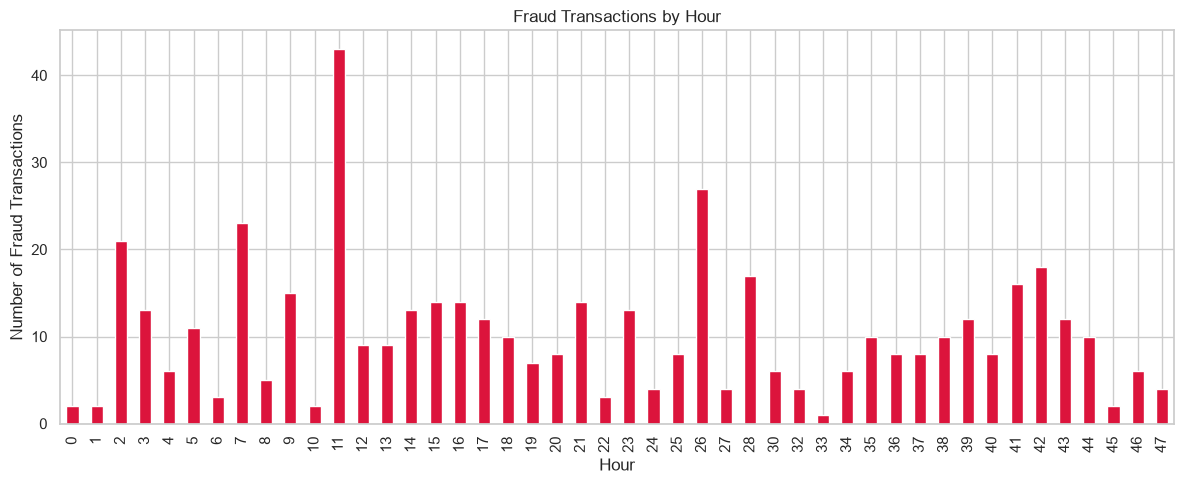

In [33]:
plt.figure(figsize=(12,5))

fraud_by_hour.plot(
    kind="bar",
    color="crimson"
)

plt.title("Fraud Transactions by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Fraud Transactions")

plt.tight_layout()

plt.savefig("images/fraud_by_hour.png", dpi=300)

plt.show()

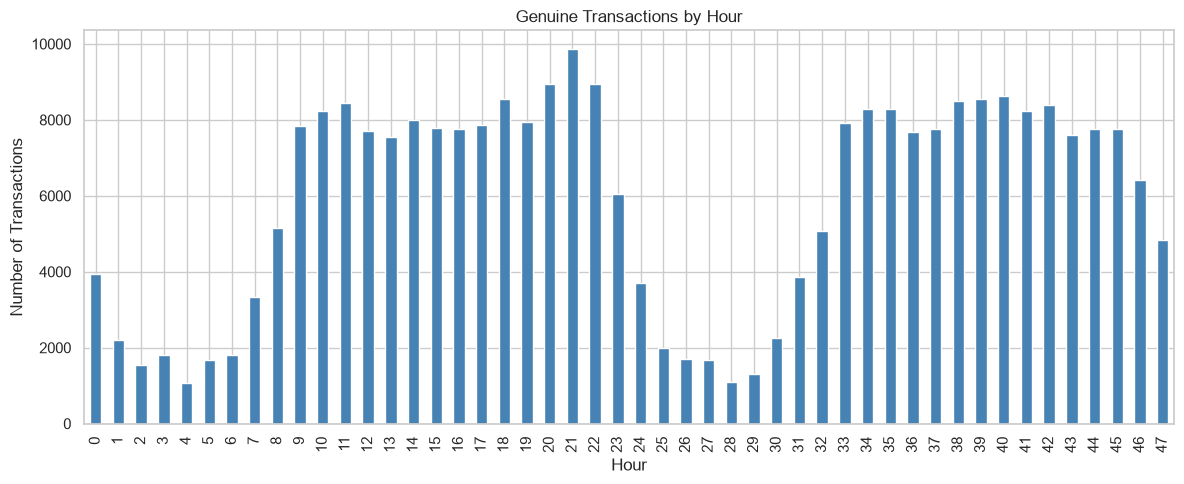

In [34]:
genuine_by_hour = (
    df[df["Class"] == 0]
    .groupby(df["Hour"].astype(int))
    .size()
)

plt.figure(figsize=(12,5))

genuine_by_hour.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Genuine Transactions by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("images/genuine_by_hour.png", dpi=300)

plt.show()

## Key Observations

- Transaction activity varies across the recorded time period.
- Fraudulent transactions occur throughout the dataset rather than being confined to a single hour.
- Some hours show relatively higher fraud activity.
- Time alone is insufficient for identifying fraudulent transactions.
- Time can become more informative when combined with other features in a machine learning model.

In [35]:
df["Hour"] = (df["Time"] // 3600).astype(int)

# Correlation Analysis

Correlation measures the strength and direction of the relationship between two variables.

A correlation heatmap provides a visual representation of these relationships and helps identify features that may be important for fraud detection.

In [36]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Display first few rows
correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359,0.999757
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486,0.118196
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624,-0.010592
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322,-0.422045
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326,-0.105827


# Correlation Heatmap

The heatmap provides a color-coded representation of feature correlations.

- Dark Red → Strong Positive Correlation
- Dark Blue → Strong Negative Correlation
- White → Weak or No Correlation

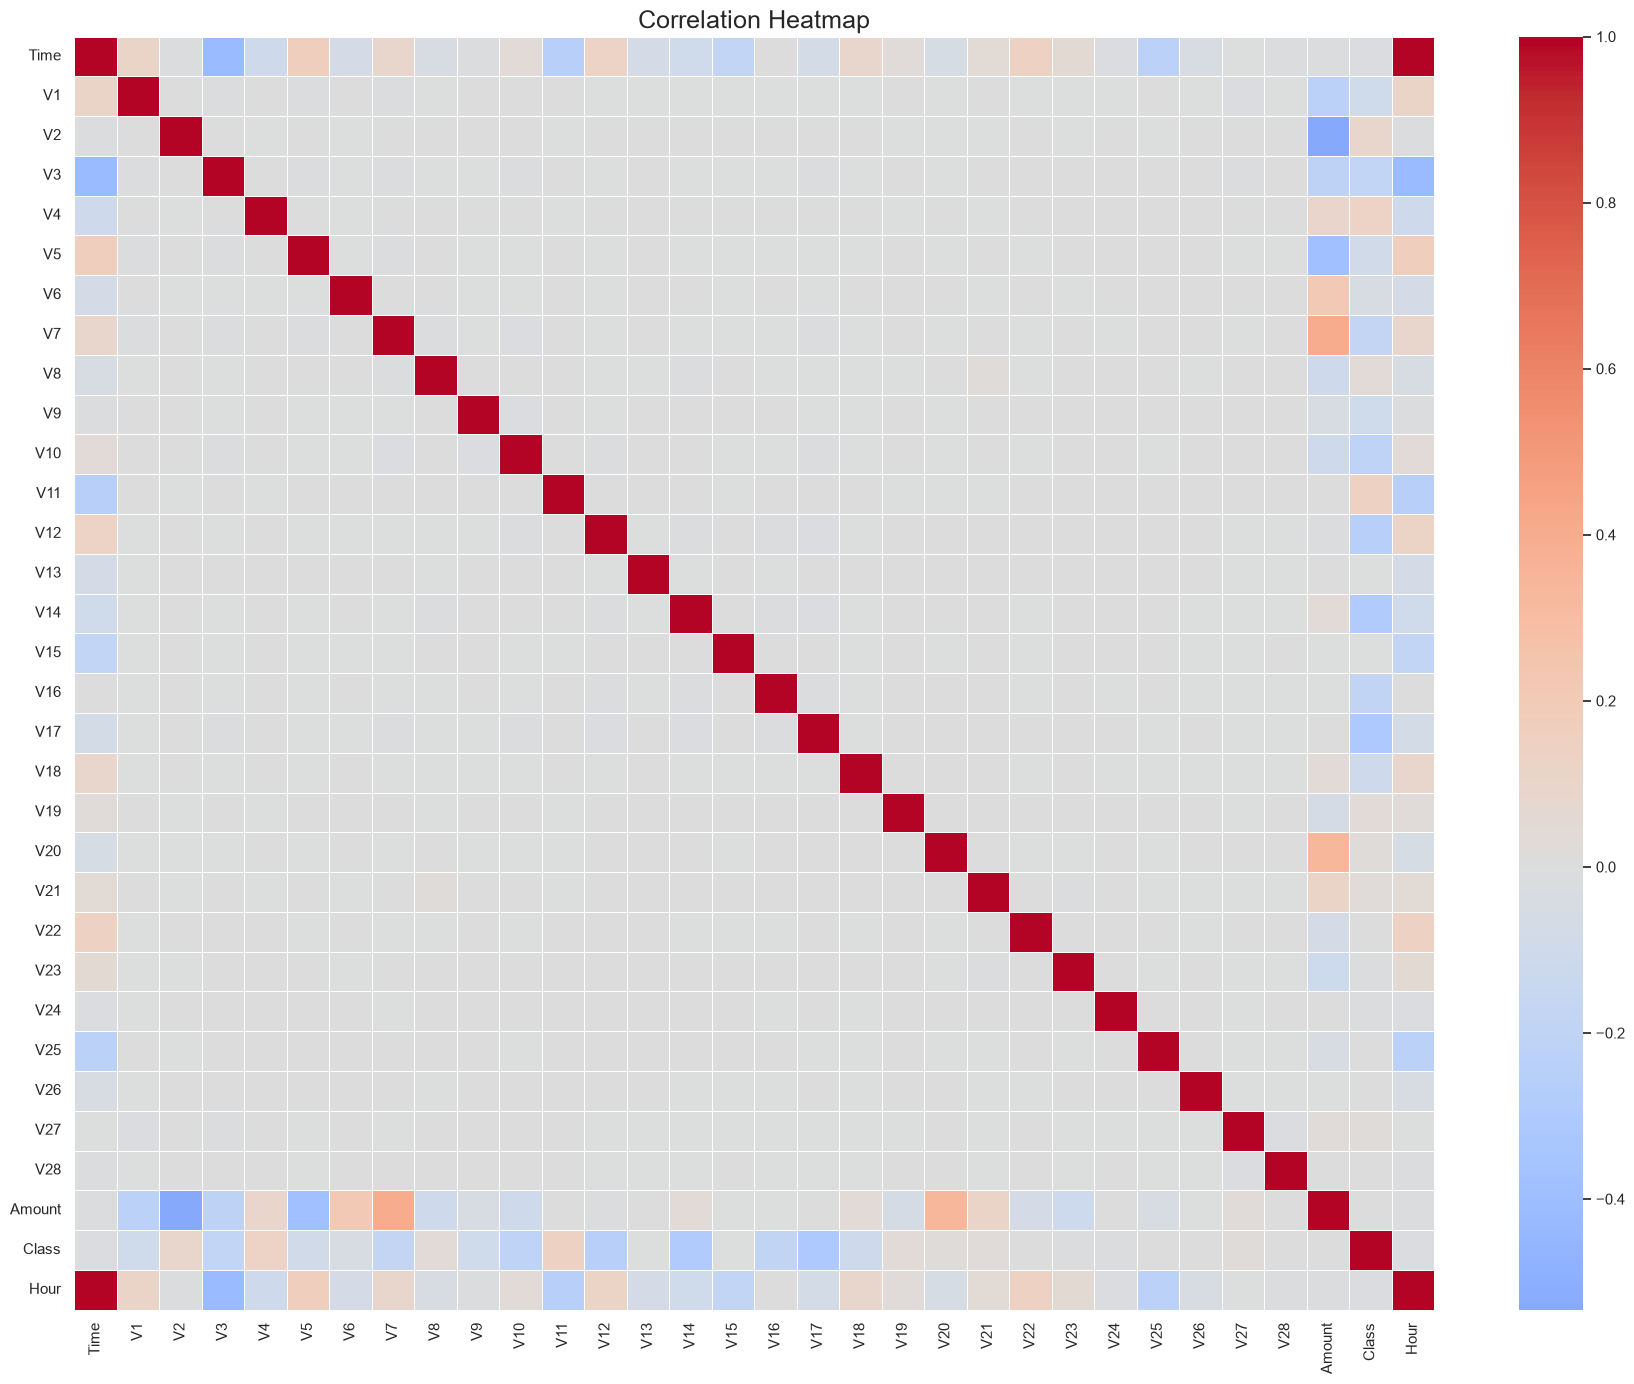

In [38]:
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.tight_layout()

plt.savefig("images/correlation_heatmap.png", dpi=300)

plt.show()

# Correlation with the Target Variable

Instead of examining all feature relationships, we now focus specifically on how each feature correlates with the target variable (Class).

In [39]:
# Correlation with the target variable
class_correlation = correlation_matrix["Class"].sort_values()

class_correlation

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Hour     -0.012371
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

# Top Features Correlated with Fraud

The following chart highlights the features most strongly associated with fraudulent transactions.

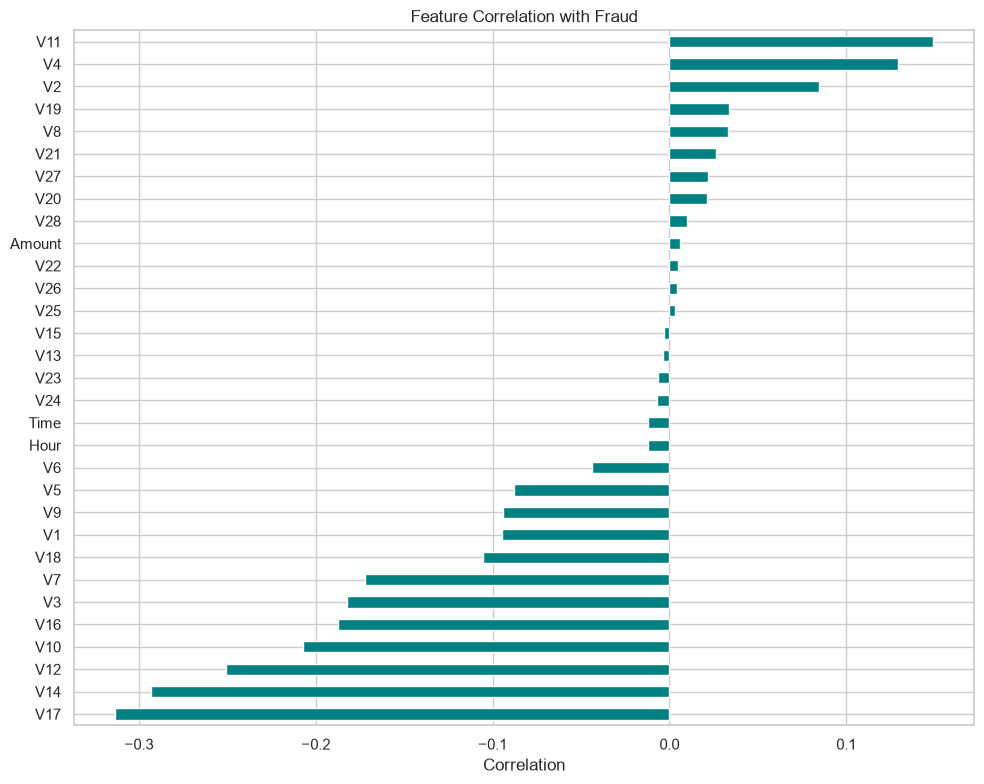

In [41]:
plt.figure(figsize=(10,8))

class_correlation.drop("Class").sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Feature Correlation with Fraud")

plt.xlabel("Correlation")

plt.tight_layout()

plt.savefig("images/class_correlation.png", dpi=300)

plt.show()

## Key Observations

- Most features exhibit weak correlations with the target variable.
- Certain PCA-transformed features demonstrate stronger positive or negative relationships with fraudulent transactions.
- Both positive and negative correlations can provide useful predictive information.
- Correlation alone is insufficient for feature selection because machine learning models can capture more complex relationships.

# Why Accuracy is Misleading

The Credit Card Fraud dataset is highly imbalanced.

A model can achieve extremely high accuracy simply by predicting every transaction as genuine.

Therefore, fraud detection models should be evaluated using:

- Precision
- Recall
- F1-score
- ROC-AUC

rather than relying on accuracy alone.

# Data Preparation

Before training machine learning models, we separate the features from the target variable.

The target variable is **Class**, where:

- 0 = Genuine Transaction
- 1 = Fraudulent Transaction

In [42]:
# Separate features and target

X = df.drop("Class", axis=1)

y = df["Class"]

print("Features shape :", X.shape)
print("Target shape   :", y.shape)

Features shape : (283726, 31)
Target shape   : (283726,)


# Train-Test Split

Machine learning models should be evaluated on unseen data.

Therefore, we divide the dataset into:

- Training Set (80%)
- Testing Set (20%)

The `stratify` parameter ensures that both sets preserve the same class distribution.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (226980, 31)
Testing Set  : (56746, 31)


In [44]:
print("Training Class Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Class Distribution")
print(y_test.value_counts(normalize=True) * 100)

Training Class Distribution
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing Class Distribution
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


# Handling Class Imbalance with SMOTE

The dataset is highly imbalanced.

Machine learning algorithms trained directly on this data are likely to become biased toward the majority class.

To address this issue, we apply the Synthetic Minority Over-sampling Technique (SMOTE) to the training data only.

In [45]:
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [46]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [47]:
from imblearn.over_sampling import SMOTE

In [48]:
import imblearn
print(imblearn.__version__)

0.14.2


# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification.

It predicts the probability that a transaction is fraudulent based on the input features.

Although it is a simple model, it provides a strong baseline for comparison.

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
# Create the Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [51]:
# Predict classes
y_pred_lr = lr_model.predict(X_test)

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [53]:
# Create the Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_smote, y_train_smote)

NameError: name 'X_train_smote' is not defined

In [54]:
from imblearn.over_sampling import SMOTE

In [55]:
smote = SMOTE(random_state=42)

In [56]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [57]:
print(X_train_smote.shape)
print(y_train_smote.shape)

print(y_train.value_counts())

print(y_train_smote.value_counts())

(453204, 31)
(453204,)
Class
0    226602
1       378
Name: count, dtype: int64
Class
0    226602
1    226602
Name: count, dtype: int64


In [58]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [59]:
y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [61]:
print("========== Logistic Regression ==========\n")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision :", precision_score(y_test, y_pred_lr))

print("Recall :", recall_score(y_test, y_pred_lr))

print("F1 Score :", f1_score(y_test, y_pred_lr))

print("ROC AUC :", roc_auc_score(y_test, y_prob_lr))

========== Logistic Regression ==========

Accuracy : 0.9879286645754767
Precision : 0.1077127659574468
Recall : 0.8526315789473684
F1 Score : 0.1912632821723731
ROC AUC : 0.9548240426842469


In [62]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.85      0.19        95

    accuracy                           0.99     56746
   macro avg       0.55      0.92      0.59     56746
weighted avg       1.00      0.99      0.99     56746



In [63]:
print("========== Random Forest ==========\n")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision :", precision_score(y_test, y_pred_rf))

print("Recall :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

========== Random Forest ==========



NameError: name 'y_pred_rf' is not defined

In [64]:
from sklearn.ensemble import RandomForestClassifier


In [65]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [66]:
rf_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
y_pred_rf = rf_model.predict(X_test)

In [68]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [69]:
print(type(y_pred_rf))
print(type(y_prob_rf))
print(len(y_pred_rf))
print(len(y_prob_rf))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
56746
56746


In [70]:
print("========== Random Forest ==========\n")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

========== Random Forest ==========

Accuracy : 0.9994713283755683
Precision : 0.9012345679012346
Recall : 0.7684210526315789
F1 Score : 0.8295454545454546
ROC AUC : 0.9460651505199426

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.95      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



# Confusion Matrix

A confusion matrix summarizes the prediction results by comparing the actual labels with the predicted labels.

It provides insight into:

- True Positives
- True Negatives
- False Positives
- False Negatives

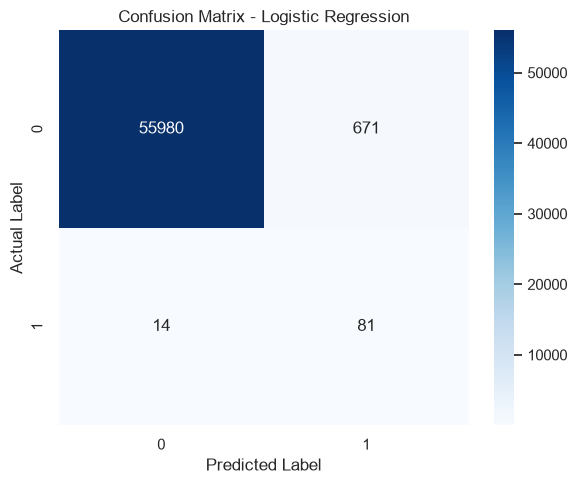

In [72]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("images/confusion_matrix_lr.png", dpi=300)

plt.show()

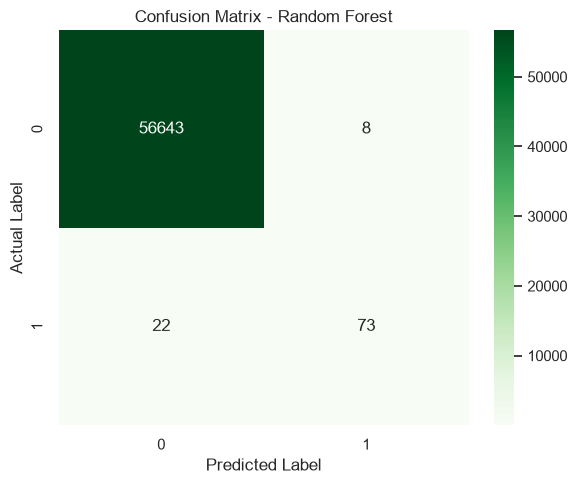

In [73]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("images/confusion_matrix_rf.png", dpi=300)

plt.show()

# ROC Curve

The ROC Curve illustrates the trade-off between the True Positive Rate and False Positive Rate.

The Area Under the Curve (ROC-AUC) summarizes the overall performance of the classifier.

In [74]:
from sklearn.metrics import roc_curve

In [75]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

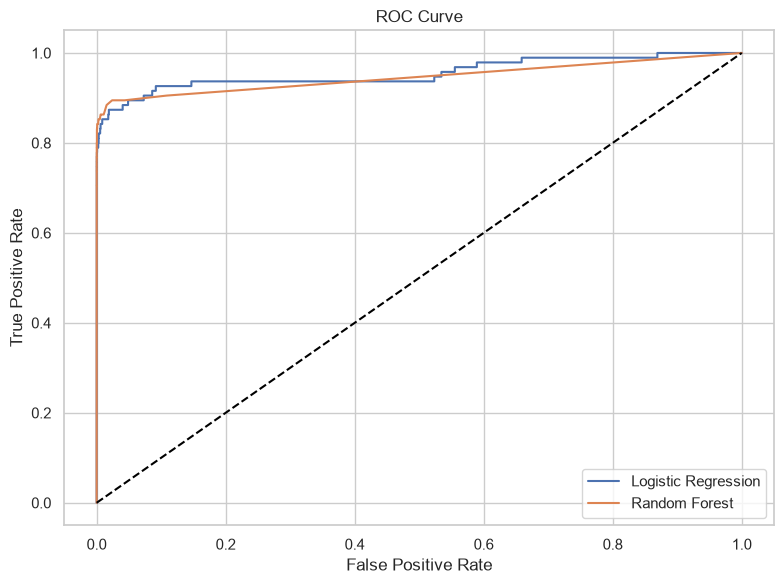

In [77]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("images/roc_curve.png", dpi=300)

plt.show()

# Feature Importance

Random Forest estimates the relative importance of each feature in making predictions.

Features with higher importance contribute more significantly to fraud detection.

In [78]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.220855
10,V10,0.160372
12,V12,0.107620
4,V4,0.094610
17,V17,0.076612
11,V11,0.071048
3,V3,0.059764
16,V16,0.028232
2,V2,0.027064
7,V7,0.026642


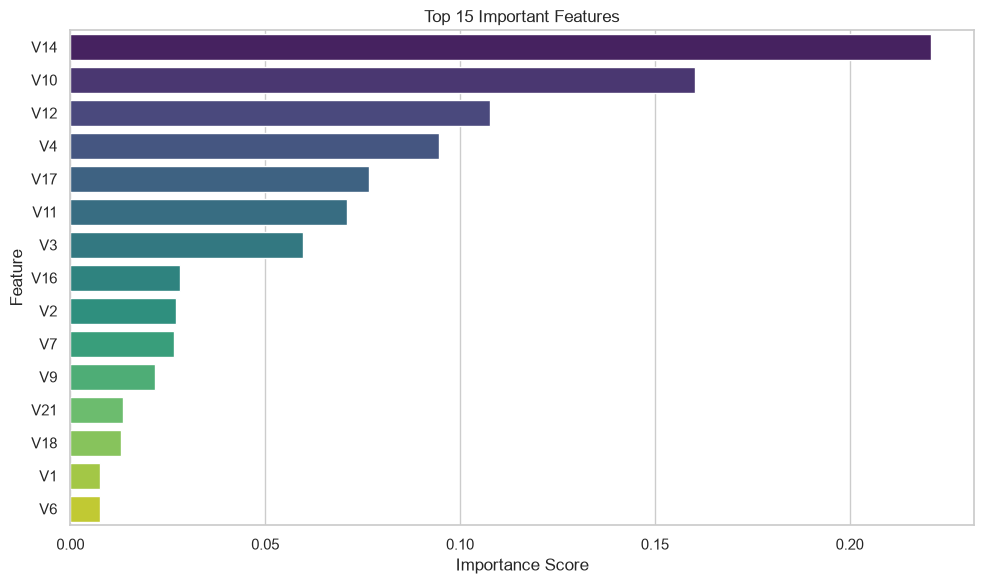

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("images/feature_importance.png", dpi=300)

plt.show()

## Key Observations

- Random Forest identifies the most influential features used during prediction.
- Several PCA-transformed variables contribute significantly to fraud detection.
- Feature importance helps interpret the model but does not imply causation.

# Precision vs Recall

Fraud detection requires balancing Precision and Recall.

**Precision** measures how many transactions predicted as fraudulent were actually fraud.

High Precision reduces false alarms and minimizes inconvenience to legitimate customers.

**Recall** measures how many actual fraudulent transactions were successfully detected.

High Recall minimizes financial losses by detecting more fraud cases.

In banking applications, Recall is generally prioritized because missing fraudulent transactions can be more costly than investigating additional suspicious transactions.

A practical fraud detection system aims to maximize Recall while maintaining acceptable Precision.

# Scalability Discussion

The current implementation is suitable for offline analysis and medium-sized datasets.

For large-scale production systems processing millions of transactions daily, additional technologies are required.

Possible improvements include:

- Distributed processing using Apache Spark
- Real-time streaming with Apache Kafka
- Cloud deployment using AWS, Azure, or Google Cloud
- Incremental model retraining
- Automated monitoring for model drift

Random Forest provides strong predictive performance but may require greater computational resources.

Logistic Regression is computationally efficient and suitable for low-latency prediction systems.

Production fraud detection systems often combine machine learning models with rule-based systems to improve reliability.

# Conclusion

This project developed an end-to-end machine learning pipeline for detecting fraudulent credit card transactions.

The dataset exhibited severe class imbalance, which was addressed using the Synthetic Minority Over-sampling Technique (SMOTE).

Two machine learning models were trained and compared:

- Logistic Regression
- Random Forest

Model performance was evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrices, and ROC Curves.

Random Forest generally achieved superior performance due to its ability to capture complex relationships among features.

The project demonstrates the complete workflow of a real-world fraud detection system, including data preprocessing, exploratory data analysis, class balancing, model training, evaluation, and interpretation.